In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import seaborn as sns

In [2]:
palette = sns.color_palette('deep')
palette

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [3]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = True

$$V_i^+ = (1 - c) \left(V_i + D \sum_j^{n} \left(\frac{V_j - V_i}{d_{ij}^2}\right)\right)$$

$$IFN_i^+ = (1 - c_F) \left(IFN_i + D_F \sum_j^{n} \left(\frac{IFN_j - IFN_i}{d_{ij}^2}\right)\right)$$

In [4]:
def sigFunc(x, A, K):
    return (1 + np.exp(-A*(x-K)))**-1

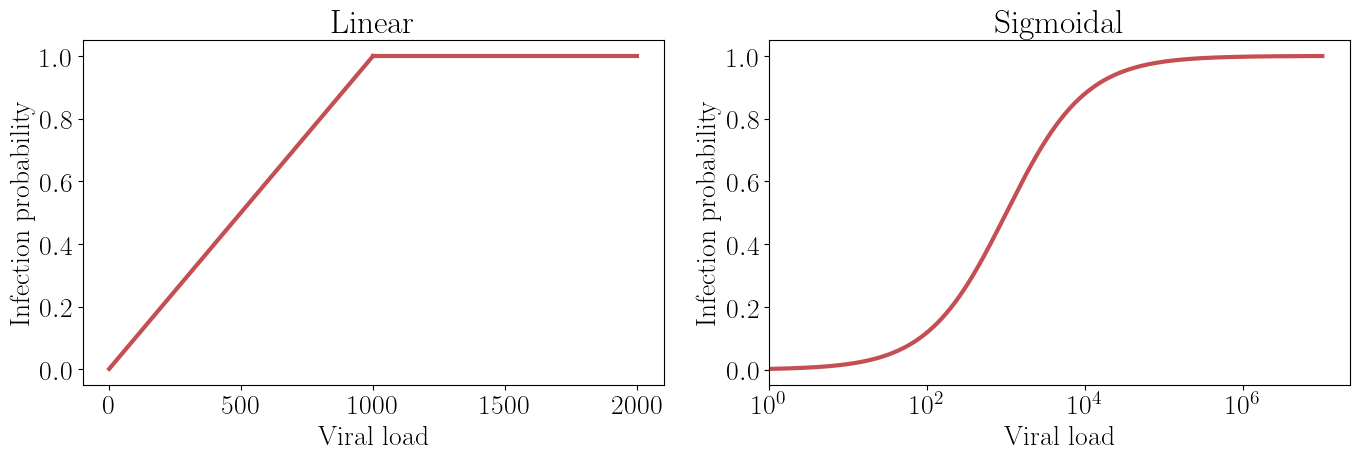

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5),facecolor='white')

A_V = 2
K_V = 3

xx1 = np.linspace(1, 1e3, num=1000)
xx2 = np.linspace(1e3, 2e3, num=1000)
yy1 = 0.001*xx1
yy2 = np.ones(len(xx2))

axs[0].set_title("Linear")
axs[0].plot(xx1, yy1, lw=3, color=palette[3])
axs[0].plot(xx2, yy2, lw=3, color=palette[3])
axs[0].set_xlabel('Viral load')
axs[0].set_ylabel('Infection probability')

xx = np.linspace(0, 7, num=1000)
x = 10**(xx)
yy1 = sigFunc(xx, A_V, K_V)

axs[1].set_title("Sigmoidal")
axs[1].plot(x, yy1, lw=3, color=palette[3])
axs[1].set_xlabel('Viral load')
axs[1].set_ylabel('Infection probability')
axs[1].set_xscale('log')
axs[1].set_xlim((1))

plt.tight_layout()
# plt.savefig('probFunctionV.png')

plt.show()

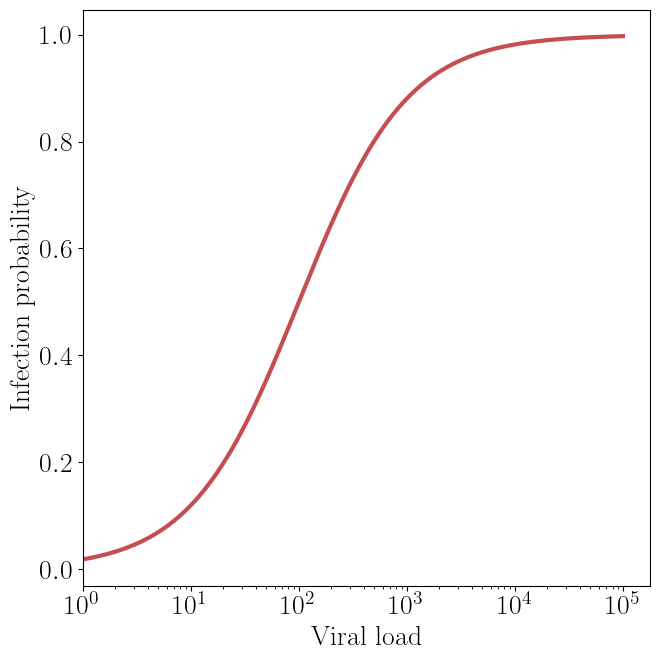

In [6]:
fig, axs = plt.subplots(figsize=(7,7),facecolor='white')

A_V = 2
K_V = 2

xx = np.linspace(0, 5, num=1000)
x = 10**(xx)
yy1 = sigFunc(xx, A_V, K_V)

axs.plot(x, yy1, lw=3, color=palette[3])
axs.set_xlabel('Viral load')
axs.set_ylabel('Infection probability')
axs.set_xscale('log')
axs.set_xlim((1))

plt.tight_layout()
# plt.savefig('probFunctionV.png')

plt.show()

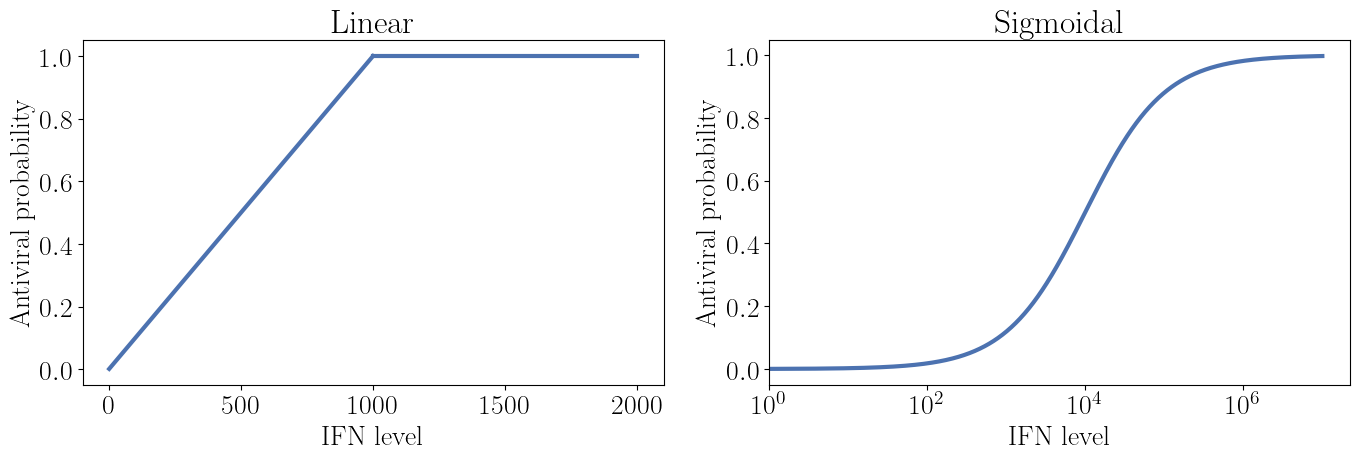

In [7]:
# fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,8),facecolor='white')
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5),facecolor='white')

A_V = 2
K_V = 4

xx1 = np.linspace(1, 1e3, num=1000)
xx2 = np.linspace(1e3, 2e3, num=1000)
yy1 = 0.001*xx1
yy2 = np.ones(len(xx2))

axs[0].set_title("Linear")
axs[0].plot(xx1, yy1, lw=3, color=palette[0])
axs[0].plot(xx2, yy2, lw=3, color=palette[0])
axs[0].set_xlabel('IFN level')
axs[0].set_ylabel('Antiviral probability')

xx = np.linspace(0, 7, num=1000)
x = 10**(xx)
yy1 = sigFunc(xx, A_V, K_V)

axs[1].set_title("Sigmoidal")
axs[1].plot(x, yy1, lw=3, color=palette[0])
axs[1].set_xlabel('IFN level')
axs[1].set_ylabel('Antiviral probability')
axs[1].set_xscale('log')
axs[1].set_xlim((1))

plt.tight_layout()
# plt.savefig('probFunctionIFN.png')

plt.show()

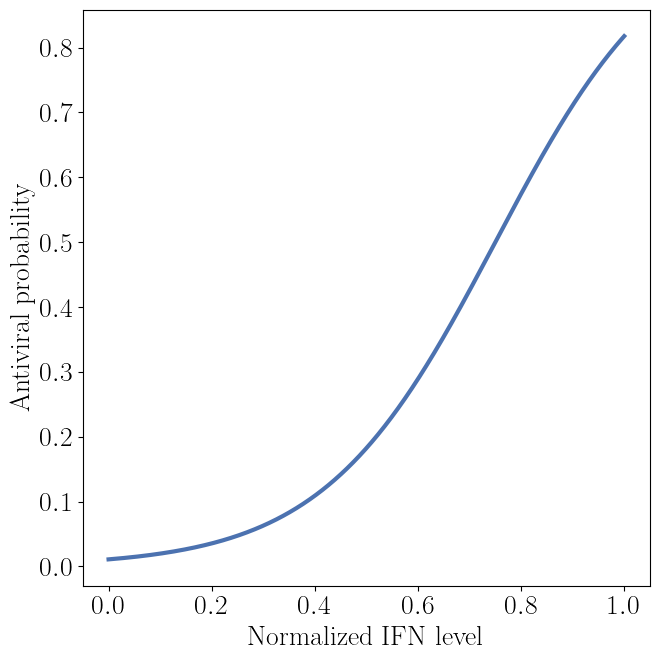

In [8]:
fig, axs = plt.subplots(figsize=(7,7),facecolor='white')

A_V = 6
K_V = 0.75

x = np.linspace(0, 1, num=1000)
yy1 = sigFunc(x, A_V, K_V)

axs.plot(x, yy1, lw=3, color=palette[0])
axs.set_xlabel('Normalized IFN level')
axs.set_ylabel('Antiviral probability')

plt.tight_layout()
# plt.savefig('probFunctionIFN.png')

plt.show()

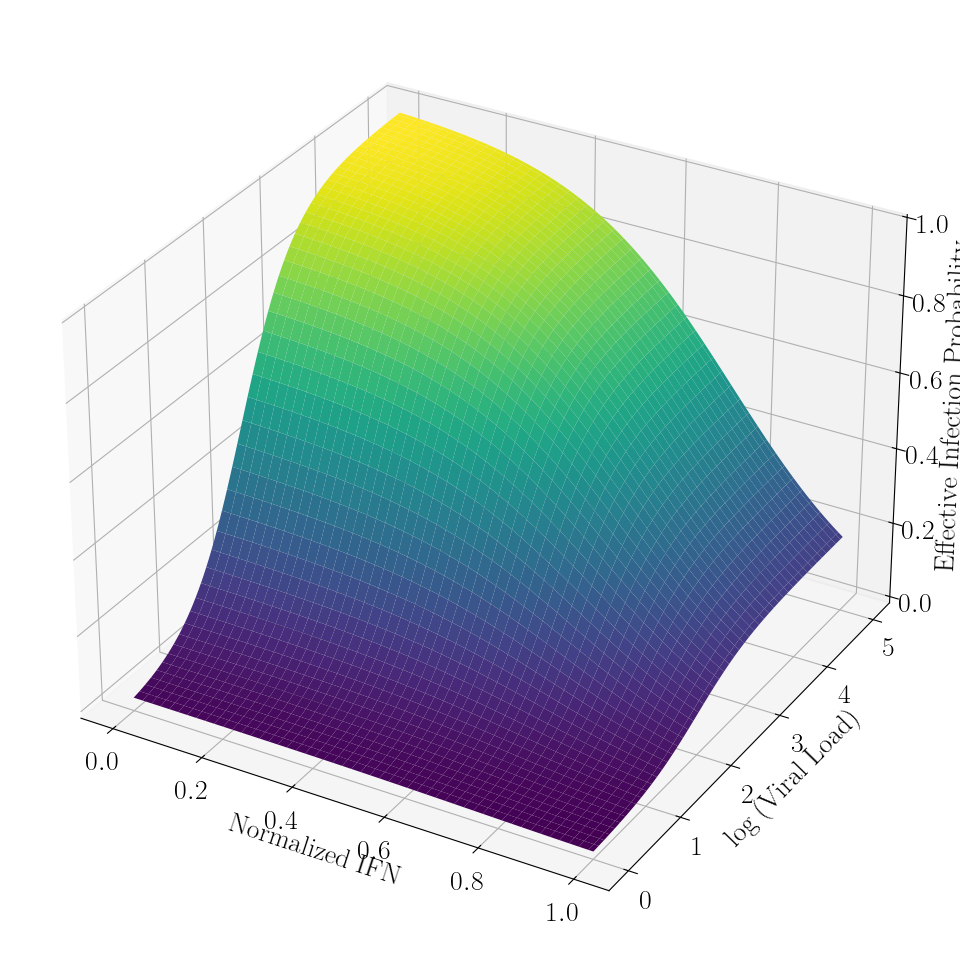

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Parameters
A_V, K_V = 2, 2        # For viral load (log10 scale)
A_F, K_F = 6, 0.75     # For IFN

# Grid for viral load (log10) and IFN
x_vals = np.linspace(0, 5, 100)      # log10(viral load)
y_vals = np.linspace(0, 1, 100)      # normalized IFN

X, Y = np.meshgrid(x_vals, y_vals)

# Compute combined probability
ViralProb = sigFunc(X, A_V, K_V)
IFNProb = sigFunc(Y, A_F, K_F)
CombinedProb = ViralProb * (1 - IFNProb)

# 3D surface plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Y, X, CombinedProb, cmap='viridis', edgecolor='none')

ax.set_ylabel('log (Viral Load)')
ax.set_xlabel('Normalized IFN')
ax.set_zlabel('Effective Infection Probability')

plt.tight_layout()

# plt.savefig('effProbInf.png')
plt.show()

In [13]:
# Load data
df = pd.read_csv('virions_per_cell.csv')
x = df['Time'].values
y = df['Virions'].values
df

,Time,Virions
0,0.033364,0.0000
1,3.936979,140.6250
2,7.907322,2835.9375
3,11.911029,6234.3750
4,16.014829,8625.0000
5,19.951807,10617.1875
6,23.888786,12820.3125
7,27.959222,14390.6250
8,31.929564,14953.1250
9,35.933272,15164.0625


In [ ]:
# # Define sigmoidal (logistic) function
# def sigmoid(t, A, k, t0):
#     return A / (1 + np.exp(-k * (t - t0)))

# # Derivative of sigmoid
# def sigmoid_derivative(t, L, k, t0):
#     exp_term = np.exp(-k * (t - t0))
#     return (L * k * exp_term) / (1 + exp_term)**2

# # Initial guess: L=max, k=1, t0=midpoint
# p0 = [max(y), 1, np.median(x)]

# # Fit
# popt, _ = curve_fit(sigmoid, x, y, p0, maxfev=10000)
# L, k, t0 = popt

# # Generate fitted curve
# x_fit = np.linspace(min(x), max(x), 200)
# y_fit = sigmoid(x_fit, *popt)

# # Compute derivative
# y_derivative = sigmoid_derivative(x_fit, *popt)

In [22]:
# Define Hill function
def hill(x, A, K, n):
    return A * (x**n) / (K**n + x**n)

# Derivative of Hill function
def hill_derivative(x, A, K, n):
    Kn = K**n
    xn = x**n
    return A * n * Kn * x**(n-1) / (Kn + xn)**2

# Initial guess: A=max, K=midpoint, n=2
p0 = [max(y), np.median(x), 2]

# Fit
popt, pcov = curve_fit(hill, x, y, p0, maxfev=10000,
                       bounds=([0, 0, 0.1], [np.inf, np.inf, 10]))
A, K, n = popt

print(f"A (max) = {A:.4f}")
print(f"K (half-max) = {K:.4f}")
print(f"n (Hill coeff) = {n:.4f}")

# Generate fitted curve and derivative
x_fit = np.linspace(min(x), max(x), 200)
y_fit = hill(x_fit, *popt)
y_derivative = hill_derivative(x_fit, *popt)

A (max) = 17783.4953
K (half-max) = 16.1392
n (Hill coeff) = 2.3613


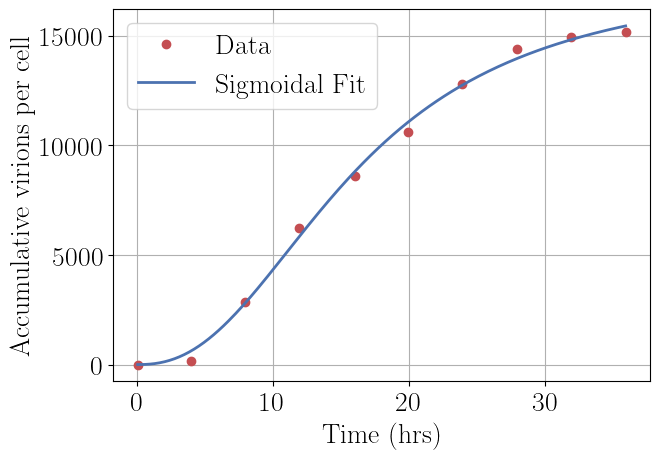

In [23]:
# Plot
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x, y, 'o', label='Data', color=palette[3])
plt.plot(x_fit, y_fit, '-', lw=2, label='Sigmoidal Fit', color=palette[0])
plt.xlabel('Time (hrs)')
plt.ylabel('Accumulative virions per cell')
plt.legend()
plt.grid(True)
plt.tight_layout()

# plt.savefig('viralProduction.png')
plt.show()

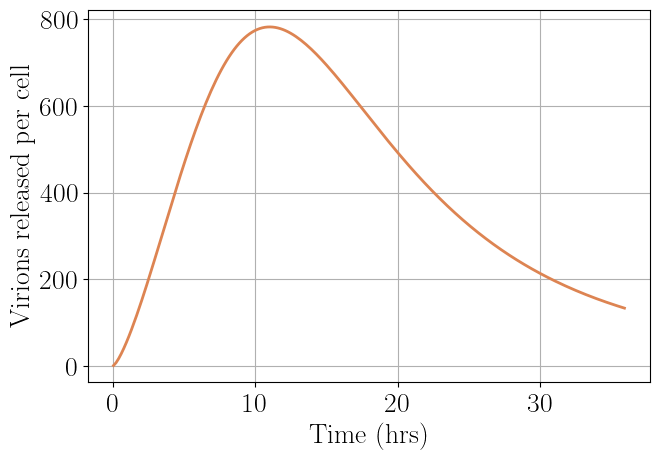

In [24]:
# Plot
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(7,5),facecolor='white')
plt.plot(x_fit, y_derivative, '-', lw=2, label='Virion release rate', color=palette[1])
plt.xlabel('Time (hrs)')
plt.ylabel('Virions released per cell')
plt.grid(True)
plt.tight_layout()

# plt.savefig('viralRate.png')
plt.show()

In [58]:
# Define sigmoidal (logistic) function
def hillIFN(t):
    A = 15164.4633
    k = 2.11574911e-01
    t0 = 1.49297062e+01
    V_cum = A / (1 + np.exp(-k * (t - t0)))
    pMax = 0.25
    Kf = A / 2
    return pMax * V_cum**2 / (Kf**2 + V_cum**2)

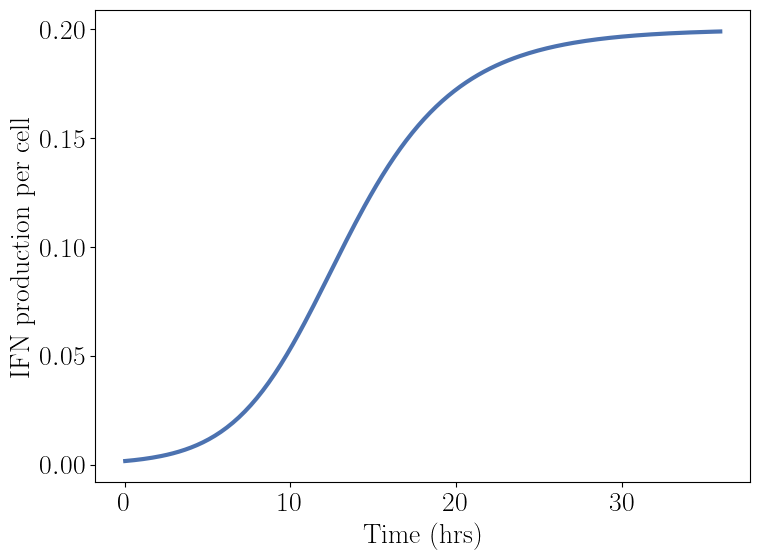

In [63]:
fig, axs = plt.subplots(figsize=(8,6),facecolor='white')

yy = hillIFN(x_fit)

axs.plot(x_fit, yy, lw=3, color=palette[0])
axs.set_xlabel('Time (hrs)')
axs.set_ylabel('IFN production per cell')

plt.tight_layout()
# plt.savefig('IFNproduction.png')

plt.show()